<a href="https://colab.research.google.com/github/22495521/99-multiplication-table/blob/main/CNN_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
# 掛載 Google Drive，讓 Colab 能讀取雲端硬碟裡的檔案
from google.colab import drive
drive.mount('/content/drive')

# 把 Drive 上的 zip 複製到 Colab 本機（/content）
# 在本機解壓和讀檔都比直接在 Drive 上操作快很多
!cp "/content/drive/MyDrive/colab_file/handwriting-data.zip" /content/

# 把 zip 解壓到 /content，解壓後資料位於 /content/data/...
# -q：安靜模式，不逐一列出解壓的檔案
# -o：強制覆寫已存在的檔案，避免出現互動提示
# -d：指定解壓的目的資料夾
!unzip -q -o /content/handwriting-data.zip -d /content

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import v2

In [45]:
IMG_SIZE = 28
train_dir = "/content/data/handwriting/augmented_images/augmented_images1"
test_dir  = "/content/data/handwriting/handwritten-english-characters-and-digits/combined_folder/test"
batch_size = 64

train_tf = v2.Compose([
    v2.ToImage(),
    v2.Grayscale(1),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.RandomCrop(IMG_SIZE, padding=4),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,)),
])

test_tf = v2.Compose([
    v2.ToImage(),
    v2.Grayscale(1),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,)),
])

trainset = datasets.ImageFolder(train_dir, transform=train_tf)
testset  = datasets.ImageFolder(test_dir,  transform=test_tf)

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,shuffle=False, num_workers=2)


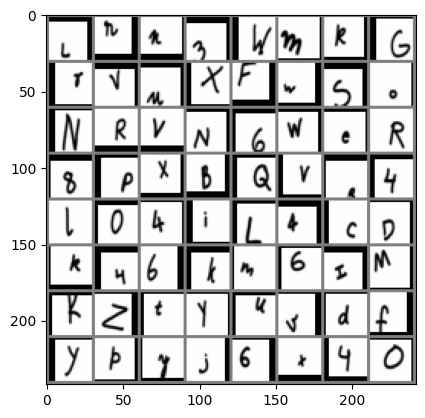

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
